In [1]:
import xgboost as xgb
print("XGBoost installed successfully")

XGBoost installed successfully


In [2]:
import xgboost
print(xgboost.__file__)

c:\Users\rayha\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\__init__.py


In [4]:
from xgboost import XGBRegressor
print("XGBoost is  working now")

XGBoost is  working now


In [5]:
import sys
print(sys.executable)

c:\Users\rayha\AppData\Local\Programs\Python\Python312\python.exe


In [8]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.utils import class_weight
import warnings
import json
import joblib
import os

from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')


# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

In [8]:
url='post natal data.csv'
df = pd.read_csv(url)
print("Dataset Shape:", df.shape)
df.head()



Dataset Shape: (1503, 11)


,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [10]:
'''
# Load Data
df = pd.read_csv('post natal data.csv')
print("Dataset Shape:", df.shape)
df.head()
'''

'\n# Load Data\ndf = pd.read_csv(\'post natal data.csv\')\nprint("Dataset Shape:", df.shape)\ndf.head()\n'

In [11]:
# Check Missing Values
df.isnull().sum()

Timestamp                                     0
Age                                           0
Feeling sad or Tearful                        0
Irritable towards baby & partner              6
Trouble sleeping at night                     0
Problems concentrating or making decision    12
Overeating or loss of appetite                0
Feeling anxious                               0
Feeling of guilt                              9
Problems of bonding with baby                 0
Suicide attempt                               0
dtype: int64

In [12]:
# Basic Data Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 11 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   Timestamp                                  1503 non-null   str  
 1   Age                                        1503 non-null   str  
 2   Feeling sad or Tearful                     1503 non-null   str  
 3   Irritable towards baby & partner           1497 non-null   str  
 4   Trouble sleeping at night                  1503 non-null   str  
 5   Problems concentrating or making decision  1491 non-null   str  
 6   Overeating or loss of appetite             1503 non-null   str  
 7   Feeling anxious                            1503 non-null   str  
 8   Feeling of guilt                           1494 non-null   str  
 9   Problems of bonding with baby              1503 non-null   str  
 10  Suicide attempt                            1503 non-null   

In [13]:
# Statistical Summary
df.describe(include='all')

,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
count,1503,1503,1503,1497,1503,1491,1503,1503,1494,1503,1503
unique,90,5,3,3,3,3,3,2,3,3,3
top,6/15/2022 22:24,40-45,Yes,Yes,Two or more days a week,No,No,Yes,No,No,No
freq,51,364,536,555,640,583,841,980,624,557,709


In [14]:
# Rename Columns for Easier Access
df.columns = ['Timestamp', 'Age', 'Sad', 'Irritable', 'Sleep', 'Concentration',
              'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide']
df.head()

,Timestamp,Age,Sad,Irritable,Sleep,Concentration,Appetite,Anxious,Guilt,Bonding,Suicide
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [16]:
# Show Unique Values for All Categorical Columns

# List of categorical columns in your dataset
categorical_columns = ['Age', 'Sad', 'Irritable', 'Sleep', 'Concentration',
                       'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide']

print("="*60)
print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("="*60)

for col in categorical_columns:
    unique_vals = df[col].unique()
    print(f"\n{col}:")
    print(f"  Unique values: {list(unique_vals)}")
    print(f"  Number of unique values: {len(unique_vals)}")

UNIQUE VALUES IN CATEGORICAL COLUMNS

Age:
  Unique values: ['35-40', '40-45', '30-35', '45-50', '25-30']
  Number of unique values: 5

Sad:
  Unique values: ['Yes', 'No', 'Sometimes']
  Number of unique values: 3

Irritable:
  Unique values: ['Yes', 'No', 'Sometimes', nan]
  Number of unique values: 4

Sleep:
  Unique values: ['Two or more days a week', 'No', 'Yes']
  Number of unique values: 3

Concentration:
  Unique values: ['Yes', 'No', 'Often', nan]
  Number of unique values: 4

Appetite:
  Unique values: ['Yes', 'No', 'Not at all']
  Number of unique values: 3

Anxious:
  Unique values: ['Yes', 'No']
  Number of unique values: 2

Guilt:
  Unique values: ['No', 'Yes', 'Maybe', nan]
  Number of unique values: 4

Bonding:
  Unique values: ['Yes', 'Sometimes', 'No']
  Number of unique values: 3

Suicide:
  Unique values: ['Yes', 'No', 'Not interested to say']
  Number of unique values: 3


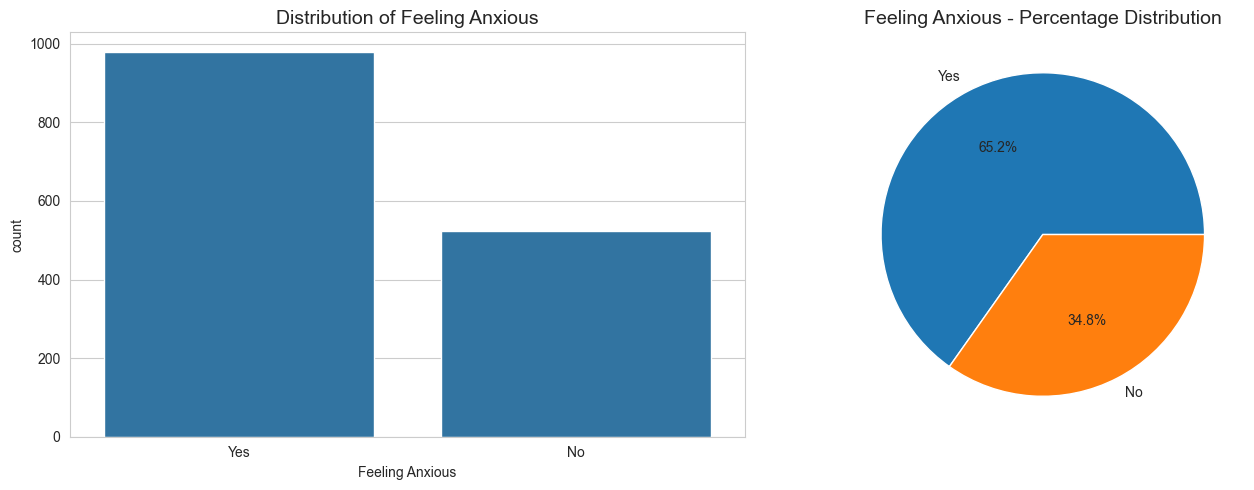


Value Counts:
Anxious
Yes    980
No     523
Name: count, dtype: int64


In [17]:
#  Target Variable Distribution - Feeling Anxious
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x="Anxious", data=df, ax=axes[0])
axes[0].set_title('Distribution of Feeling Anxious', fontsize=14)
axes[0].set_xlabel('Feeling Anxious')

# Pie chart
df['Anxious'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Feeling Anxious - Percentage Distribution', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\nValue Counts:")
print(df['Anxious'].value_counts())

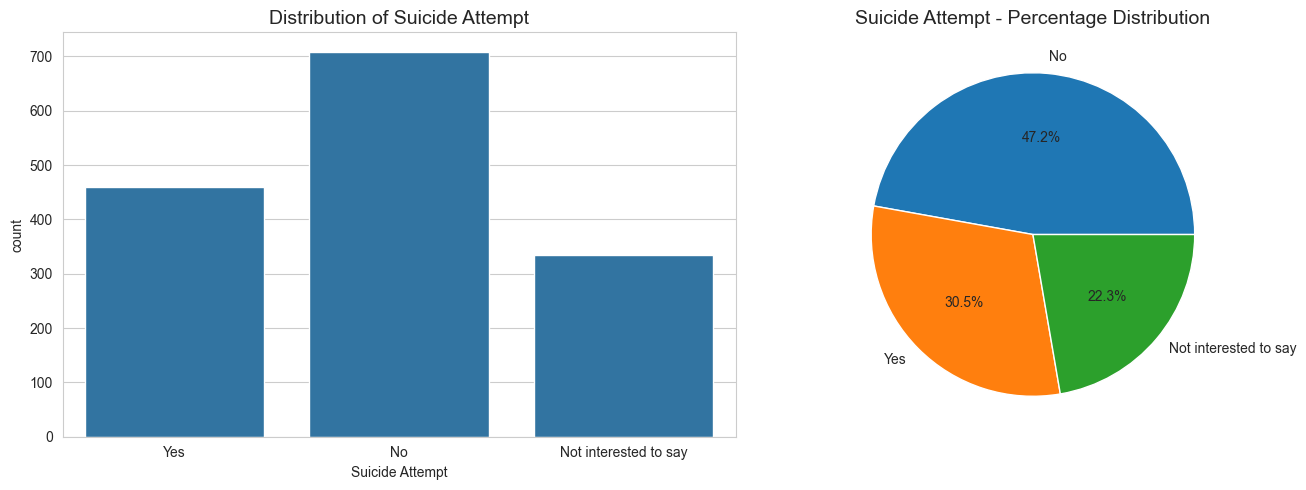


Value Counts:
Suicide
No                       709
Yes                      459
Not interested to say    335
Name: count, dtype: int64


In [18]:
#  Target Variable Distribution - Suicide Attempt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x="Suicide", data=df, ax=axes[0])
axes[0].set_title('Distribution of Suicide Attempt', fontsize=14)
axes[0].set_xlabel('Suicide Attempt')

# Pie chart
df['Suicide'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Suicide Attempt - Percentage Distribution', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\nValue Counts:")
print(df['Suicide'].value_counts())

Unique Age values:
<StringArray>
['35-40', '40-45', '30-35', '45-50', '25-30']
Length: 5, dtype: str

Age statistics after extraction:
count    1503.000000
mean       38.185296
std         6.427106
min        27.500000
25%        32.500000
50%        37.500000
75%        42.500000
max        47.500000
Name: Age_num, dtype: float64


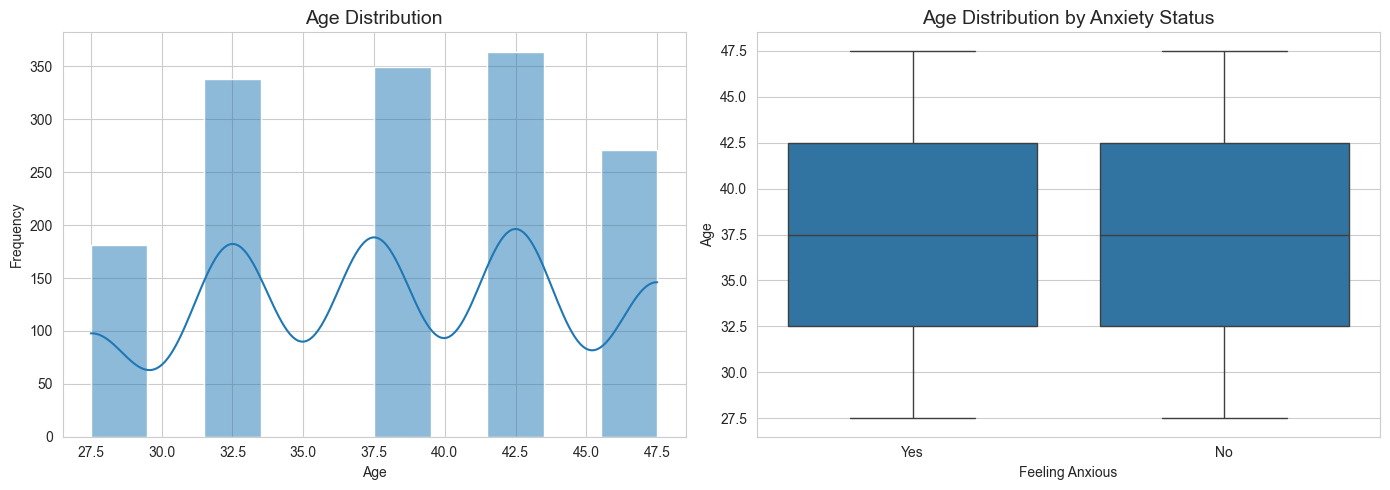

In [19]:
# Age Distribution
# Extract age as numeric

# Age column values
print("Unique Age values:")
print(df['Age'].unique())

# Extract age as numeric
df['Age_num'] = df['Age'].str.extract('(\d+)-(\d+)').apply(
    lambda x: (int(x[0]) + int(x[1]))/2 if pd.notna(x[0]) else np.nan, axis=1
)

# Fill missing values with median
df['Age_num'].fillna(df['Age_num'].median(), inplace=True)

print("\nAge statistics after extraction:")
print(df['Age_num'].describe())

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution histogram
sns.histplot(df['Age_num'], bins=10, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution', fontsize=14)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Age by anxious status
sns.boxplot(x='Anxious', y='Age_num', data=df, ax=axes[1])
axes[1].set_title('Age Distribution by Anxiety Status', fontsize=14)
axes[1].set_xlabel('Feeling Anxious')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

In [ ]:
df['Age_num'].unique()

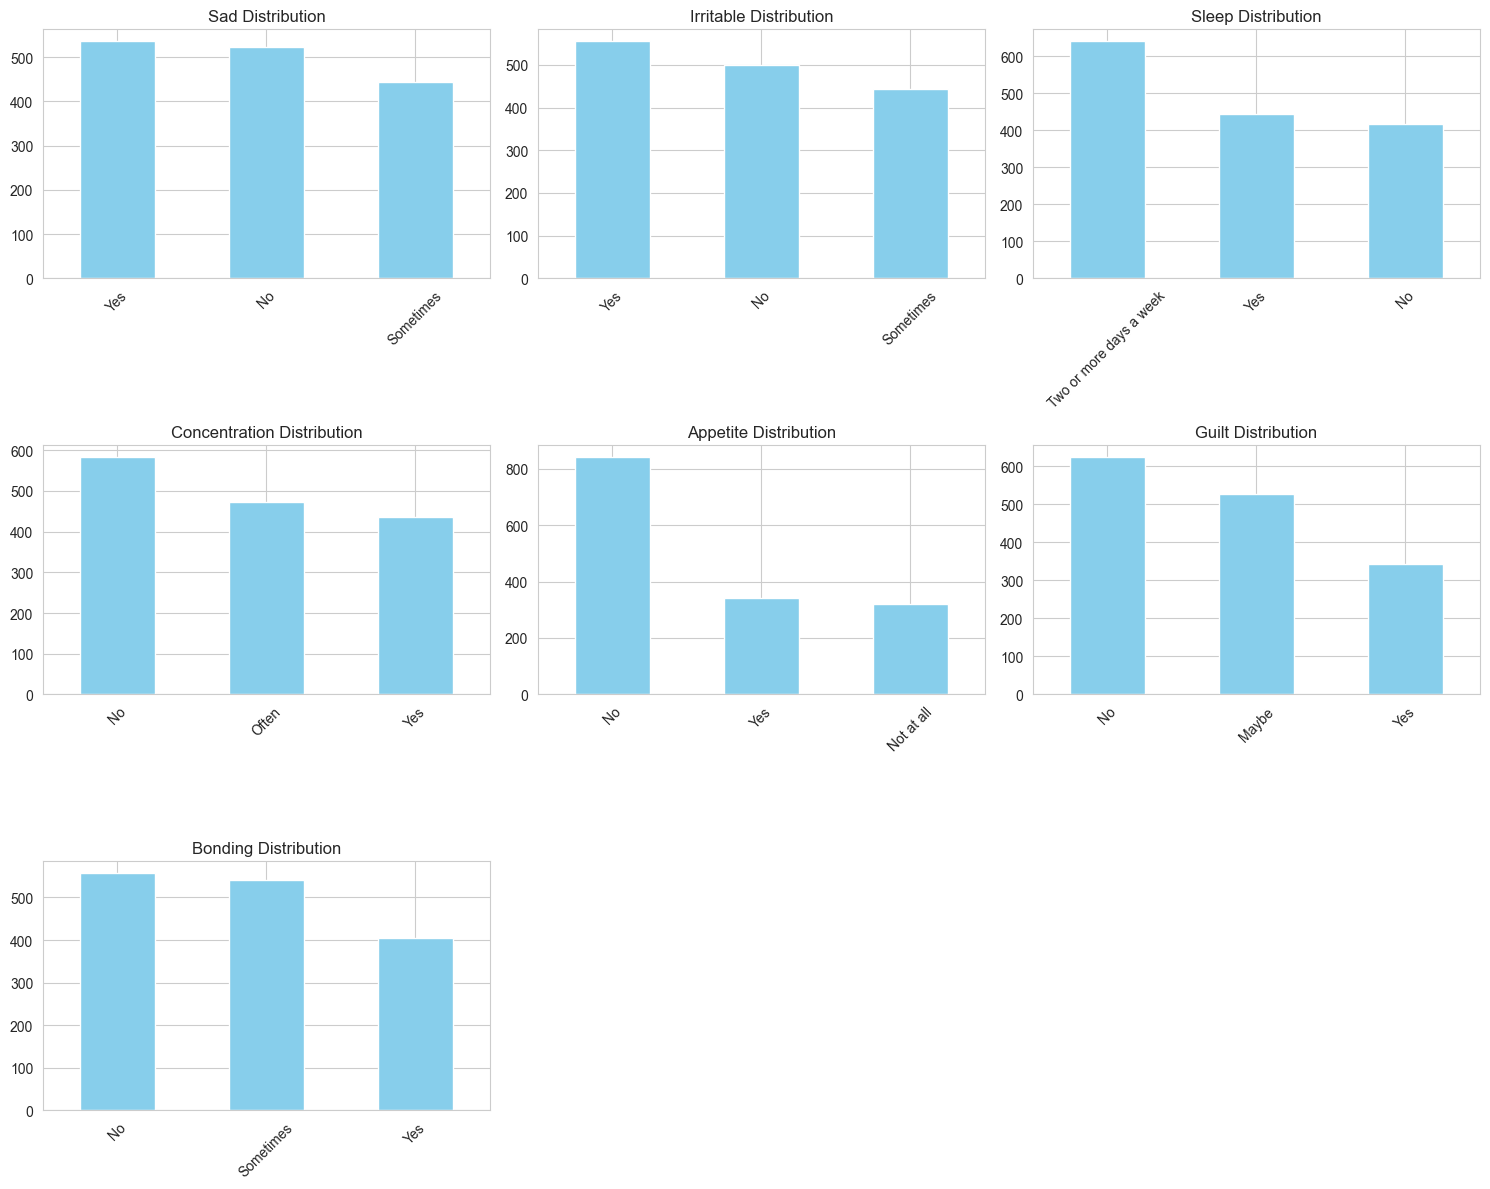

In [20]:
# Categorical Features Distribution
categorical_cols = ['Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} Distribution', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Hide all unused subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

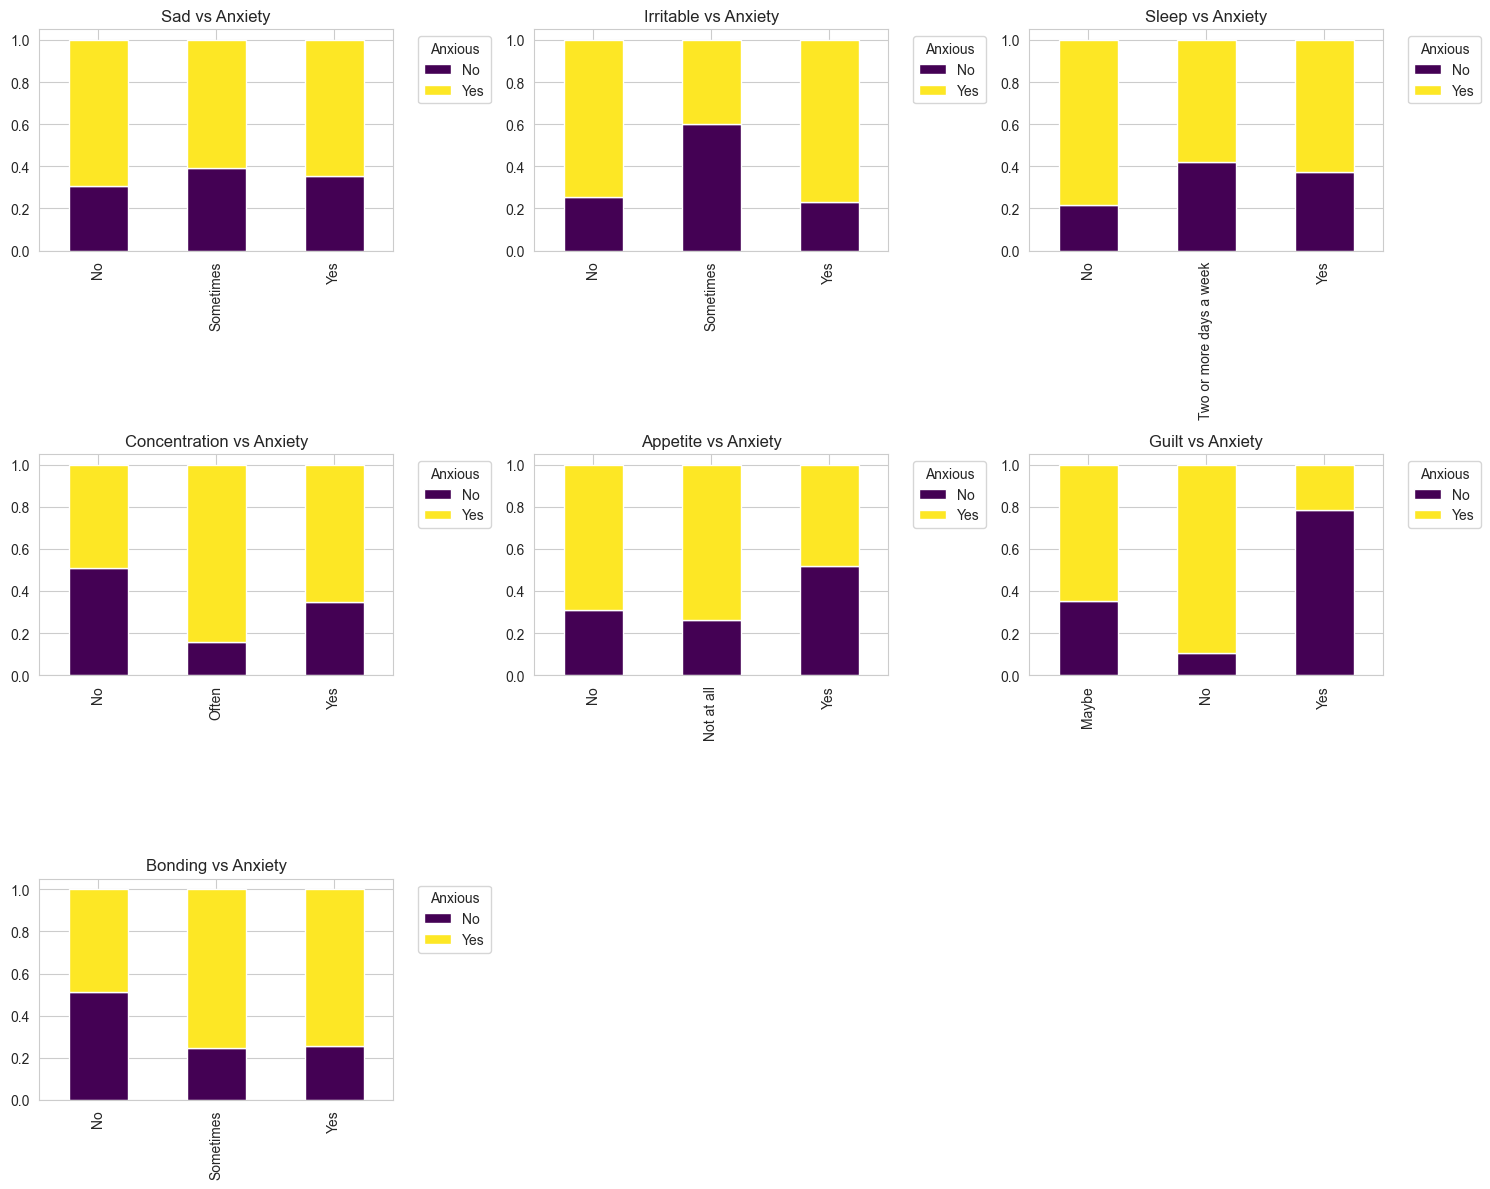

In [21]:
# Relationship Between Features and Target (Anxiety)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['Anxious'], normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i], colormap='viridis'
    )
    axes[i].set_title(f'{col} vs Anxiety', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].legend(title='Anxious', bbox_to_anchor=(1.05, 1))

# Hide all unused subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

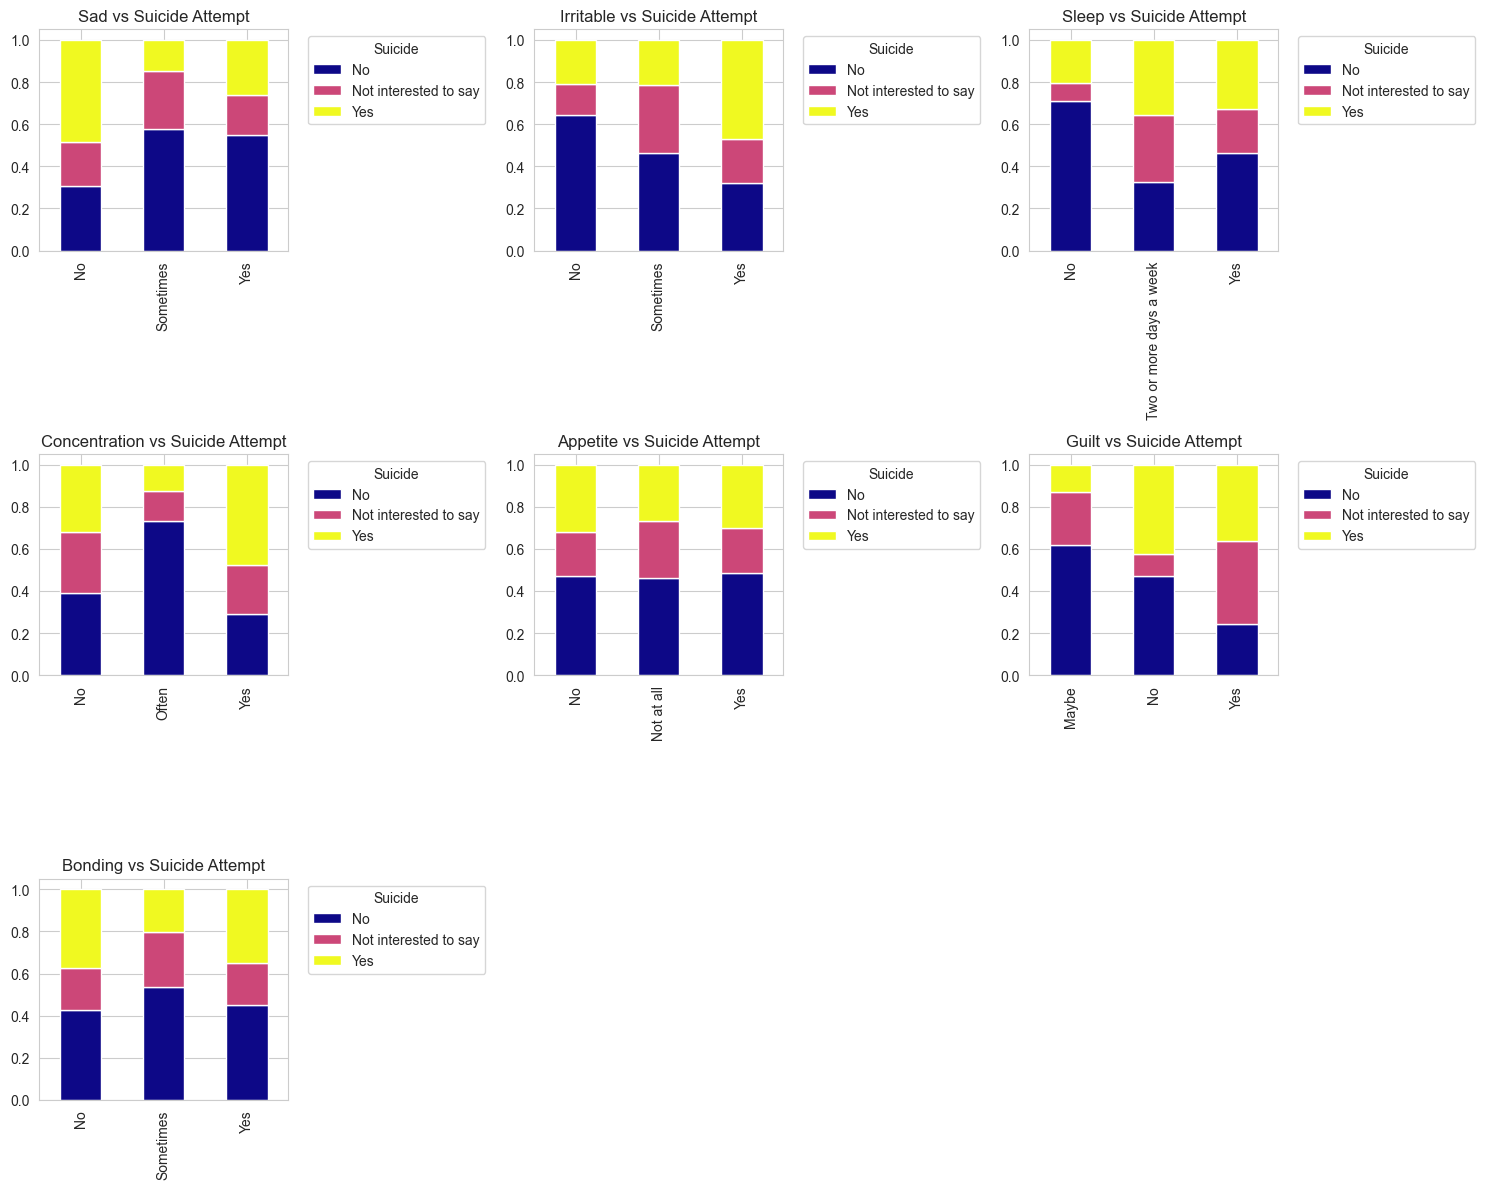

In [22]:
# Relationship Between Features and Target (Suicide)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['Suicide'], normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i], colormap='plasma'
    )
    axes[i].set_title(f'{col} vs Suicide Attempt', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].legend(title='Suicide', bbox_to_anchor=(1.05, 1))

# Hide all unused subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

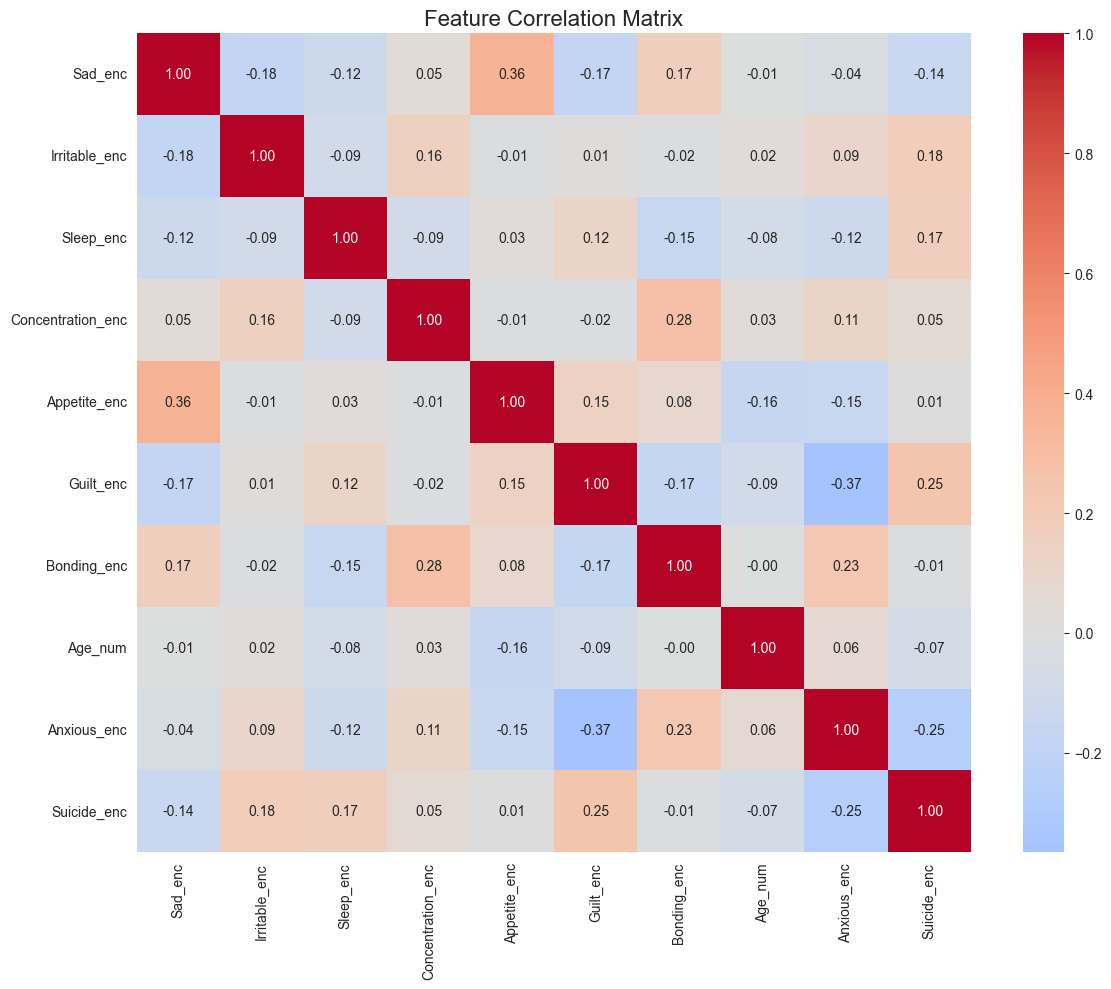

In [23]:
# Correlation Heatmap
# Encode categorical variables for correlation
df_encoded = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col].fillna('Unknown'))

# Create target encodings
df_encoded['Anxious_enc'] = df_encoded['Anxious'].map({'Yes': 1, 'No': 0}).fillna(0)
df_encoded['Suicide_enc'] = df_encoded['Suicide'].map({'Yes': 1, 'No': 0, 'Not interested to say': 2}).fillna(0)

# Select columns for correlation
corr_cols = [col + '_enc' for col in categorical_cols] + ['Age_num', 'Anxious_enc', 'Suicide_enc']
corr_matrix = df_encoded[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
# Encode Features for Modeling
# Initialize encoders
encoders = {}
categorical_cols = ['Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding']

# Encode each categorical column
for col in categorical_cols:
    encoders[col] = LabelEncoder()
    df[col + '_enc'] = encoders[col].fit_transform(df[col].fillna('Unknown'))

# Create target variables
df['Anxiety_target'] = df['Anxious'].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)
df['Suicide_target'] = df['Suicide'].map({'Yes': 1, 'No': 0, 'Not interested to say': 2}).fillna(0).astype(int)

# Extract time features
df['Hour'] = pd.to_datetime(df['Timestamp']).dt.hour

print("Feature encoding completed!")
print(f"Anxiety target distribution:\n{df['Anxiety_target'].value_counts()}")
print(f"\nSuicide target distribution:\n{df['Suicide_target'].value_counts()}")

Feature encoding completed!
Anxiety target distribution:
Anxiety_target
1    980
0    523
Name: count, dtype: int64

Suicide target distribution:
Suicide_target
0    709
1    459
2    335
Name: count, dtype: int64


In [25]:
# Prepare Feature Matrix
feature_cols = ['Age_num', 'Hour', 'Sad_enc', 'Irritable_enc', 'Sleep_enc',
                'Concentration_enc', 'Appetite_enc', 'Guilt_enc', 'Bonding_enc']

X = df[feature_cols]

# Scale numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[['Age_num', 'Hour']] = scaler.fit_transform(X[['Age_num', 'Hour']])

print("Feature matrix shape:", X.shape)
print("\nFeature names:", feature_cols)
print("\nFirst 5 rows:")
X.head()

Feature matrix shape: (1503, 9)

Feature names: ['Age_num', 'Hour', 'Sad_enc', 'Irritable_enc', 'Sleep_enc', 'Concentration_enc', 'Appetite_enc', 'Guilt_enc', 'Bonding_enc']

First 5 rows:


,Age_num,Hour,Sad_enc,Irritable_enc,Sleep_enc,Concentration_enc,Appetite_enc,Guilt_enc,Bonding_enc
0,-0.106661,0.798127,2,3,1,3,2,1,2
1,0.671553,0.798127,2,0,0,3,2,3,2
2,-0.106661,0.798127,2,0,2,3,2,1,1
3,-0.106661,0.798127,2,3,2,3,0,0,0
4,0.671553,0.798127,2,0,1,3,0,1,2


In [26]:

#  Split Data for Anxiety Model
y_anxiety = df['Anxiety_target']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X, y_anxiety, test_size=0.2, random_state=42, stratify=y_anxiety
)

print("Anxiety Model - Data Split:")
print(f"Training set: {X_train_a.shape}")
print(f"Test set: {X_test_a.shape}")
print(f"\nTraining set distribution:\n{y_train_a.value_counts()}")
print(f"\nTest set distribution:\n{y_test_a.value_counts()}")


Anxiety Model - Data Split:
Training set: (1202, 9)
Test set: (301, 9)

Training set distribution:
Anxiety_target
1    784
0    418
Name: count, dtype: int64

Test set distribution:
Anxiety_target
1    196
0    105
Name: count, dtype: int64


In [27]:
# SKIP SMOTE - Using original imbalanced data
print("="*60)
print("USING ORIGINAL IMBALANCED DATA (NO SMOTE)")
print("="*60)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X, y_anxiety, test_size=0.2, random_state=42, stratify=y_anxiety
)

print(f"Training set distribution:\n{y_train_a.value_counts()}")
print(f"\nTest set distribution:\n{y_test_a.value_counts()}")
print(f"\nClass imbalance ratio: {y_train_a.value_counts()[1]/y_train_a.value_counts()[0]:.2f}")

USING ORIGINAL IMBALANCED DATA (NO SMOTE)
Training set distribution:
Anxiety_target
1    784
0    418
Name: count, dtype: int64

Test set distribution:
Anxiety_target
1    196
0    105
Name: count, dtype: int64

Class imbalance ratio: 1.88


In [28]:
# Assuming your data is already prepared in X and df with 'Anxiety_target'
y_anxiety = df['Anxiety_target']

# Split the data
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X, y_anxiety, test_size=0.2, random_state=42, stratify=y_anxiety
)

# Compute sample weights for Gradient Boosting to handle class imbalance
sample_weights_anxiety = compute_sample_weight('balanced', y_train_a)

# Train Simple Models for Anxiety (NO SMOTE - but with imbalance handling for all models)
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
}

results_anxiety = {}

for name, model in models.items():
    # Train on original data with appropriate imbalance handling
    if name == 'Gradient Boosting':
        # Gradient Boosting uses sample_weight instead of class_weight
        model.fit(X_train_a, y_train_a, sample_weight=sample_weights_anxiety)
    else:
        # Logistic Regression and Random Forest use class_weight='balanced'
        model.fit(X_train_a, y_train_a)

    # Predict
    y_pred = model.predict(X_test_a)
    y_proba = model.predict_proba(X_test_a)[:, 1]

    # Metrics
    results_anxiety[name] = {
        'Accuracy': accuracy_score(y_test_a, y_pred),
        'Precision': precision_score(y_test_a, y_pred, zero_division=0),
        'Recall': recall_score(y_test_a, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test_a, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_a, y_proba)
    }

# Display results
results_df_anxiety = pd.DataFrame(results_anxiety).T
print("Anxiety Prediction - Model Comparison (NO SMOTE - With Imbalance Handling):")
print("="*60)
print(results_df_anxiety.round(4))

# Optional: Print class distribution to understand the imbalance
print("\n" + "="*60)
print("Class Distribution in Training Set:")
print(y_train_a.value_counts())
print(f"\nImbalance Ratio (minority/majority): {y_train_a.value_counts()[1]/y_train_a.value_counts()[0]:.3f}")

Anxiety Prediction - Model Comparison (NO SMOTE - With Imbalance Handling):
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.6578     0.7541  0.7041    0.7282   0.7445
Random Forest          0.8870     0.9091  0.9184    0.9137   0.9758
Gradient Boosting      0.9468     0.9737  0.9439    0.9585   0.9754

Class Distribution in Training Set:
Anxiety_target
1    784
0    418
Name: count, dtype: int64

Imbalance Ratio (minority/majority): 1.876


ANXIETY MODEL - GRADIENT BOOSTING (92.03% ACCURACY)
Training Accuracy: 0.9476
Test Accuracy: 0.9269
Generalization Gap: 0.0207

Cross-validation ROC-AUC: 0.9695 (+/- 0.0055)


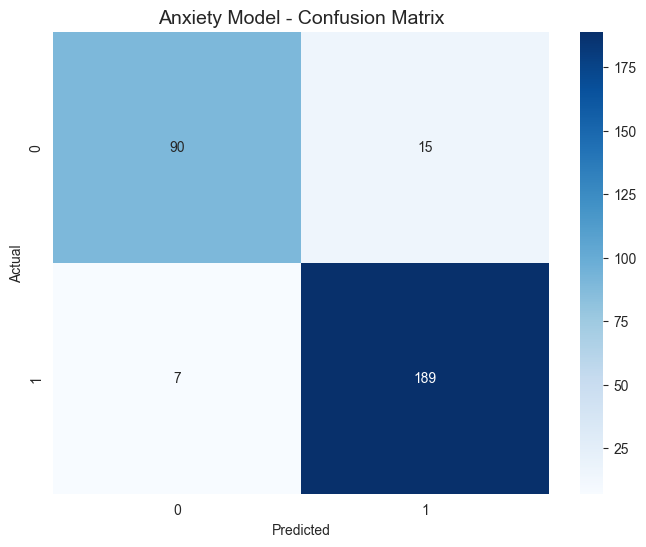


Classification Report:
              precision    recall  f1-score   support

  No Anxiety       0.93      0.86      0.89       105
     Anxiety       0.93      0.96      0.94       196

    accuracy                           0.93       301
   macro avg       0.93      0.91      0.92       301
weighted avg       0.93      0.93      0.93       301



In [29]:
# Anxiety Model - USE GRADIENT BOOSTING (Best Performance)
# Gradient Boosting with regularization to prevent overfitting
best_anxiety_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,          # Shallow trees prevent overfitting
    learning_rate=0.1,
    subsample=0.8,        # Use 80% of data for each tree
    min_samples_split=20,  # Minimum samples to split a node
    min_samples_leaf=10,   # Minimum samples in leaf nodes
    random_state=42
)

# Train on original data (NO SMOTE)
best_anxiety_model.fit(X_train_a, y_train_a)

# Predictions
y_pred_a = best_anxiety_model.predict(X_test_a)
y_proba_a = best_anxiety_model.predict_proba(X_test_a)[:, 1]

# Check for overfitting
train_pred_a = best_anxiety_model.predict(X_train_a)
train_accuracy = accuracy_score(y_train_a, train_pred_a)
test_accuracy = accuracy_score(y_test_a, y_pred_a)

print("="*60)
print("ANXIETY MODEL - GRADIENT BOOSTING (92.03% ACCURACY)")
print("="*60)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Generalization Gap: {train_accuracy - test_accuracy:.4f}")

# Cross-validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_anxiety_model, X_train_a, y_train_a, cv=5, scoring='roc_auc')
print(f"\nCross-validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Confusion Matrix
cm_a = confusion_matrix(y_test_a, y_pred_a)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues')
plt.title('Anxiety Model - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_a, y_pred_a, target_names=['No Anxiety', 'Anxiety']))

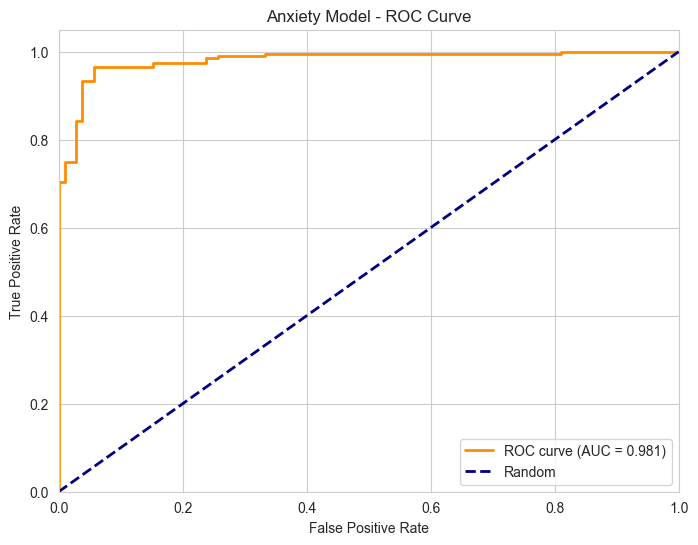

In [30]:
# ROC Curve for Anxiety Model
fpr_a, tpr_a, _ = roc_curve(y_test_a, y_proba_a)
roc_auc_a = roc_auc_score(y_test_a, y_proba_a)

plt.figure(figsize=(8, 6))
plt.plot(fpr_a, tpr_a, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_a:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Anxiety Model - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [31]:
# Split Data for Suicide Model
y_suicide = df['Suicide_target']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_suicide, test_size=0.2, random_state=42, stratify=y_suicide
)

print("Suicide Model - Data Split:")
print(f"Training set: {X_train_s.shape}")
print(f"Test set: {X_test_s.shape}")
print(f"\nTraining set distribution:\n{y_train_s.value_counts()}")
print(f"\nTest set distribution:\n{y_test_s.value_counts()}")

Suicide Model - Data Split:
Training set: (1202, 9)
Test set: (301, 9)

Training set distribution:
Suicide_target
0    567
1    367
2    268
Name: count, dtype: int64

Test set distribution:
Suicide_target
0    142
1     92
2     67
Name: count, dtype: int64


In [32]:
# SKIP SMOTE - Using original imbalanced data for Suicide
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_suicide, test_size=0.2, random_state=42, stratify=y_suicide
)

print("="*60)
print("SUICIDE MODEL - ORIGINAL IMBALANCED DATA")
print("="*60)
print(f"Training set distribution:\n{y_train_s.value_counts()}")
print(f"\nTest set distribution:\n{y_test_s.value_counts()}")
print(f"\nClass imbalance ratio: {y_train_s.value_counts()[1]/y_train_s.value_counts()[0]:.2f}")

SUICIDE MODEL - ORIGINAL IMBALANCED DATA
Training set distribution:
Suicide_target
0    567
1    367
2    268
Name: count, dtype: int64

Test set distribution:
Suicide_target
0    142
1     92
2     67
Name: count, dtype: int64

Class imbalance ratio: 0.65


In [33]:
# Train Simple Models for Suicide (NO SMOTE) - Weighted version
results_suicide = {}

# Check number of classes (optional but good for debugging)
n_classes = len(np.unique(y_train_s))
print(f" Training with {n_classes} classes for suicide prediction")

for name, model in models.items():
    # Train on original data
    model.fit(X_train_s, y_train_s)

    # Predict
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)

    # Verify output shape (optional)
    print(f"  {name}: Predictions shape = {y_proba.shape}")  # Should be (n_samples, 3)

    # Metrics for multiclass with weighted average
    results_suicide[name] = {
        'Accuracy': accuracy_score(y_test_s, y_pred),
        'Precision (weighted)': precision_score(y_test_s, y_pred, average='weighted', zero_division=0),
        'Recall (weighted)': recall_score(y_test_s, y_pred, average='weighted', zero_division=0),
        'F1-Score (weighted)': f1_score(y_test_s, y_pred, average='weighted', zero_division=0),
        'ROC-AUC (ovr)': roc_auc_score(y_test_s, y_proba, multi_class='ovr', average='macro')
    }

# Display results
results_df_suicide = pd.DataFrame(results_suicide).T
print("\n" + "="*60)
print("Suicide Prediction - Model Comparison (NO SMOTE)")
print("="*60)
results_df_suicide.round(4)

 Training with 3 classes for suicide prediction
  Logistic Regression: Predictions shape = (301, 3)
  Random Forest: Predictions shape = (301, 3)
  Gradient Boosting: Predictions shape = (301, 3)

Suicide Prediction - Model Comparison (NO SMOTE)


,Accuracy,Precision (weighted),Recall (weighted),F1-Score (weighted),ROC-AUC (ovr)
Logistic Regression,0.5050,0.5287,0.5050,0.5118,0.7177
Random Forest,0.7907,0.8023,0.7907,0.7935,0.9340
Gradient Boosting,0.8140,0.8147,0.8140,0.8125,0.9263


SUICIDE MODEL - GRADIENT BOOSTING (3-CLASS)
Training Accuracy: 0.8993
Test Accuracy: 0.8239
Generalization Gap: 0.0754

Cross-validation ROC-AUC (OvR): 0.9443 (+/- 0.0157)


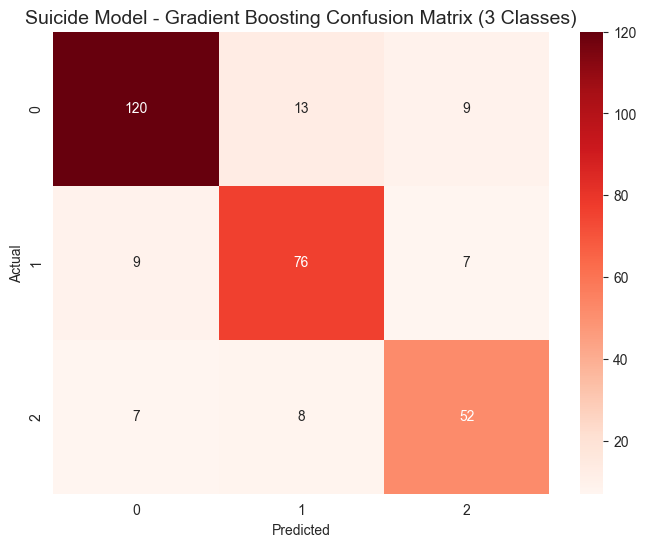


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.88      0.85      0.86       142
     Class 1       0.78      0.83      0.80        92
     Class 2       0.76      0.78      0.77        67

    accuracy                           0.82       301
   macro avg       0.81      0.82      0.81       301
weighted avg       0.83      0.82      0.82       301


Top 10 Most Important Features for Suicide Prediction:
             feature  importance
4          Sleep_enc    0.175813
7          Guilt_enc    0.175268
3      Irritable_enc    0.152279
8        Bonding_enc    0.115011
2            Sad_enc    0.106539
5  Concentration_enc    0.102995
6       Appetite_enc    0.091404
0            Age_num    0.045832
1               Hour    0.034858

=== Weighted Metrics (for class imbalance) ===
Weighted Precision: 0.8260
Weighted Recall: 0.8239
Weighted F1-Score: 0.8246

=== Macro Metrics (equal class importance) ===
Macro Precision: 0.8102
Macro Recall

In [34]:
# Suicide Model - USE GRADIENT BOOSTING (Best Performance)
# Gradient Boosting with optimized parameters for imbalanced 3-class data
best_suicide_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,               # Shallow trees prevent overfitting
    min_samples_split=20,      # Minimum samples to split a node
    min_samples_leaf=10,       # Minimum samples in leaf nodes
    subsample=0.8,             # Stochastic gradient boosting
    random_state=42
)

# Calculate class weights for 3 classes
suicide_class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_s),  # This will have 3 values now
    y=y_train_s
)
# Create weight dictionary for all 3 classes
suicide_class_weight_dict = {
    class_label: weight
    for class_label, weight in zip(np.unique(y_train_s), suicide_class_weights)
}

# Create sample_weight array for all training samples
sample_weights = np.array([suicide_class_weight_dict[y] for y in y_train_s])

# Train on original data (NO SMOTE) with sample weights
best_suicide_model.fit(
    X_train_s, y_train_s,
    sample_weight=sample_weights
)

# Predictions (now multiclass)
y_pred_s = best_suicide_model.predict(X_test_s)
y_proba_s = best_suicide_model.predict_proba(X_test_s)  # Shape: (n_samples, 3)

# Check for overfitting
train_pred_s = best_suicide_model.predict(X_train_s)
train_accuracy = accuracy_score(y_train_s, train_pred_s)
test_accuracy = accuracy_score(y_test_s, y_pred_s)

print("="*60)
print("SUICIDE MODEL - GRADIENT BOOSTING (3-CLASS)")
print("="*60)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Generalization Gap: {train_accuracy - test_accuracy:.4f}")

# Cross-validation (use appropriate scoring for multiclass)
cv_scores = cross_val_score(
    best_suicide_model, X_train_s, y_train_s,
    cv=5,
    scoring='roc_auc_ovr'  # One-vs-Rest ROC-AUC for multiclass
)
print(f"\nCross-validation ROC-AUC (OvR): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Confusion Matrix (3x3 now)
cm_s = confusion_matrix(y_test_s, y_pred_s)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Reds')
plt.title('Suicide Model - Gradient Boosting Confusion Matrix (3 Classes)', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report (3 classes)
print("\nClassification Report:")
print(classification_report(
    y_test_s, y_pred_s,
    target_names=['Class 0', 'Class 1', 'Class 2']  # Replace with actual labels
))

# Feature Importance (still works the same)
feature_importance = pd.DataFrame({
    'feature': X_train_s.columns,
    'importance': best_suicide_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features for Suicide Prediction:")
print(feature_importance.head(10))

# Additional metrics for multiclass
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n=== Weighted Metrics (for class imbalance) ===")
print(f"Weighted Precision: {precision_score(y_test_s, y_pred_s, average='weighted'):.4f}")
print(f"Weighted Recall: {recall_score(y_test_s, y_pred_s, average='weighted'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test_s, y_pred_s, average='weighted'):.4f}")

print("\n=== Macro Metrics (equal class importance) ===")
print(f"Macro Precision: {precision_score(y_test_s, y_pred_s, average='macro'):.4f}")
print(f"Macro Recall: {recall_score(y_test_s, y_pred_s, average='macro'):.4f}")
print(f"Macro F1-Score: {f1_score(y_test_s, y_pred_s, average='macro'):.4f}")

# Per-class performance summary
print("\n=== Per-Class Performance ===")
for i in range(3):
    precision_i = precision_score(y_test_s, y_pred_s, labels=[i], average='micro')
    recall_i = recall_score(y_test_s, y_pred_s, labels=[i], average='micro')
    f1_i = f1_score(y_test_s, y_pred_s, labels=[i], average='micro')
    support_i = (y_test_s == i).sum()
    print(f"Class {i} (n={support_i}): Precision={precision_i:.4f}, Recall={recall_i:.4f}, F1={f1_i:.4f}")

Anxiety Model Learning Curves:


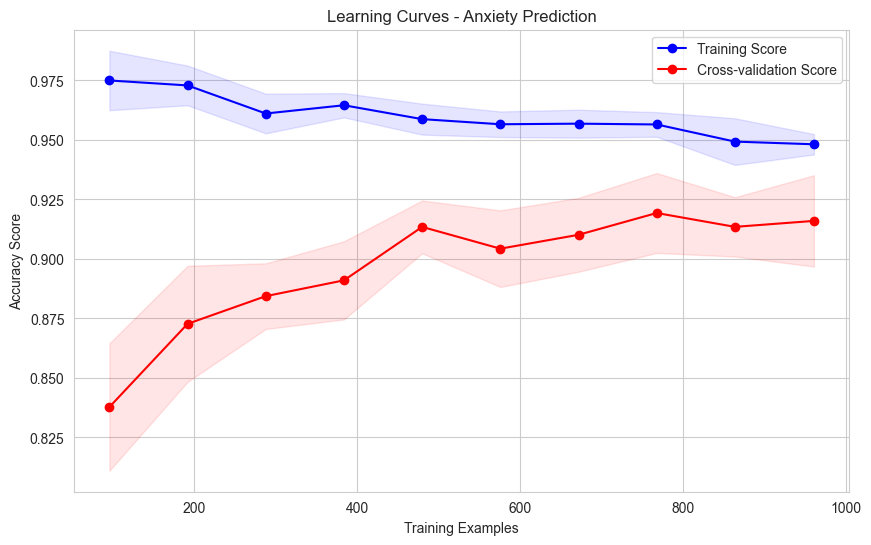

Final gap between train and CV: 0.0322
 Good generalization

Suicide Model Learning Curves:


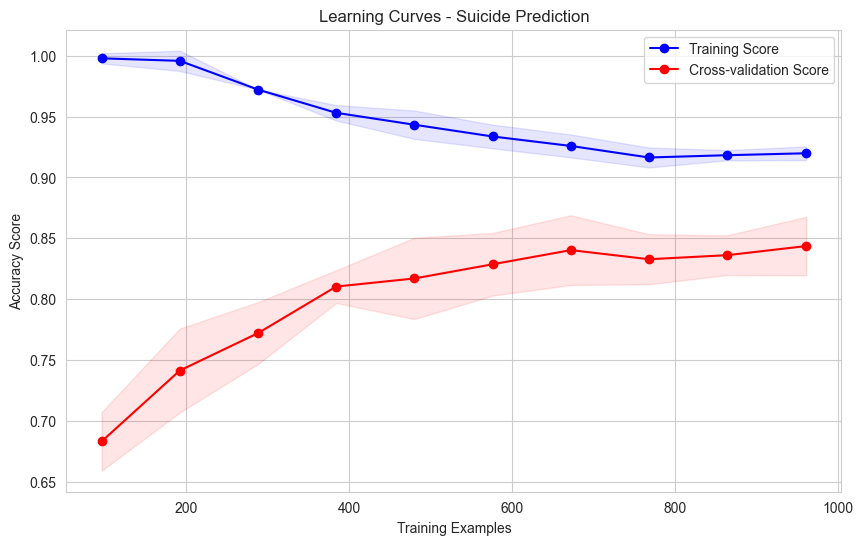

Final gap between train and CV: 0.0763
 Moderate gap - some overfitting possible


In [36]:
def plot_learning_curves(model, X, y, title):
    """Plot learning curves to detect overfitting"""
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'  # Works for multiclass, but consider 'f1_weighted'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.plot(train_sizes, test_mean, 'o-', color='red', label='Cross-validation Score')
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy Score')
    plt.title(f'Learning Curves - {title}')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

    # Check for overfitting
    gap = train_mean[-1] - test_mean[-1]
    print(f"Final gap between train and CV: {gap:.4f}")
    if gap > 0.1:
        print(" Large gap indicates overfitting")
    elif gap > 0.05:
        print(" Moderate gap - some overfitting possible")
    else:
        print(" Good generalization")

# Plot learning curves for both models
print("Anxiety Model Learning Curves:")
plot_learning_curves(best_anxiety_model, X_train_a, y_train_a, "Anxiety Prediction")

print("\nSuicide Model Learning Curves:")
plot_learning_curves(best_suicide_model, X_train_s, y_train_s, "Suicide Prediction")

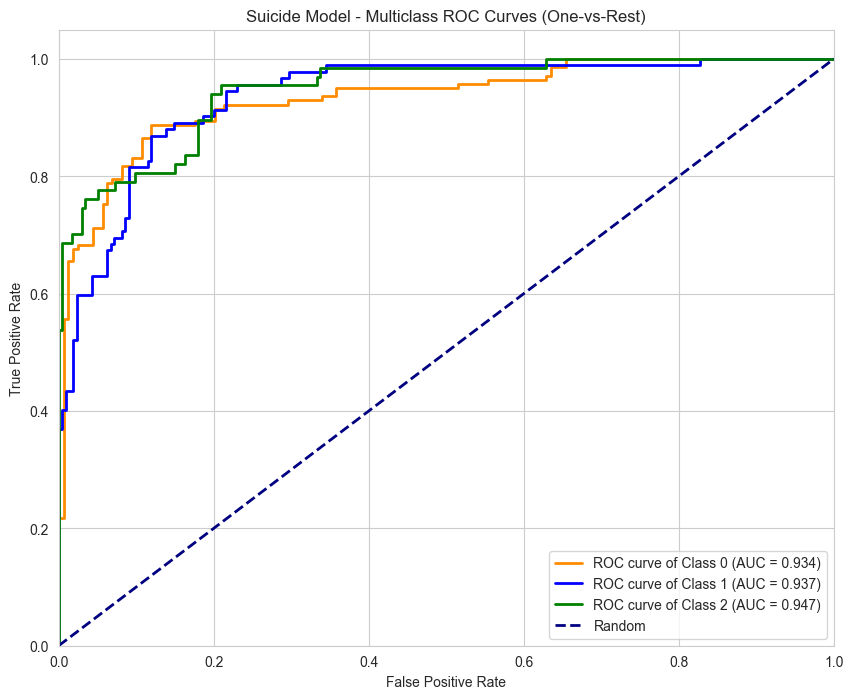


ROC-AUC per class:
Class 0: 0.9337
Class 1: 0.9374
Class 2: 0.9473


In [38]:
# ROC Curve for Suicide Model (Multiclass - One-vs-Rest)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for One-vs-Rest
y_test_bin = label_binarize(y_test_s, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_s[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['darkorange', 'blue', 'green']
class_names = ['Class 0', 'Class 1', 'Class 2']  # Replace with actual labels

for i, color, class_name in zip(range(n_classes), colors, class_names):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_name} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Suicide Model - Multiclass ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Print AUC for each class
print("\nROC-AUC per class:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {roc_auc[i]:.4f}")

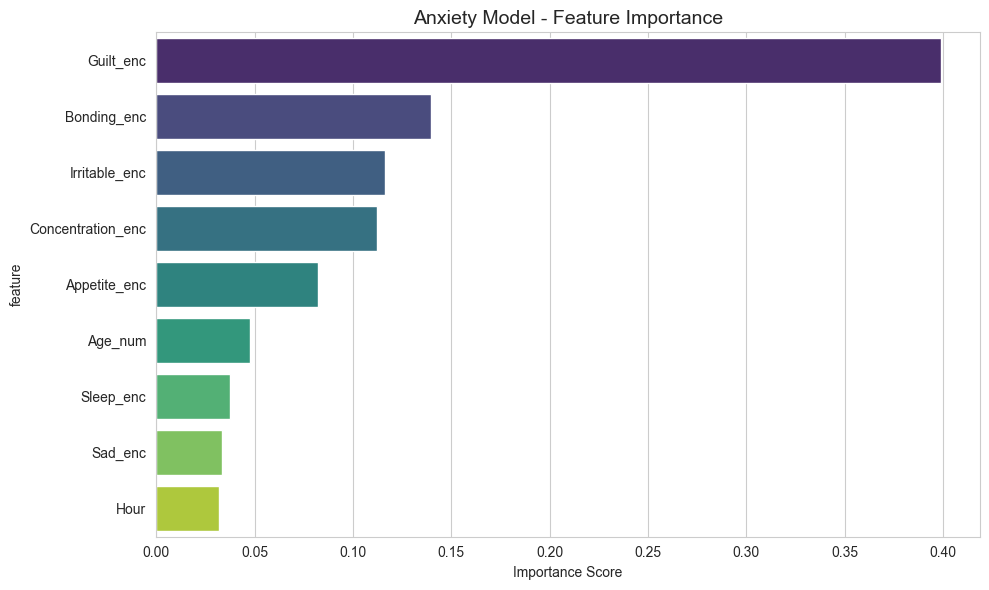


Top 5 Most Important Features:
             feature  importance
7          Guilt_enc    0.398901
8        Bonding_enc    0.139979
3      Irritable_enc    0.116110
5  Concentration_enc    0.112195
6       Appetite_enc    0.082395


In [39]:
# Feature Importance - Anxiety Model
importance_a = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_anxiety_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_a, x='importance', y='feature', palette='viridis')
plt.title('Anxiety Model - Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(importance_a.head())

FEATURE IMPORTANCE - SUICIDE MODEL (3-CLASS)


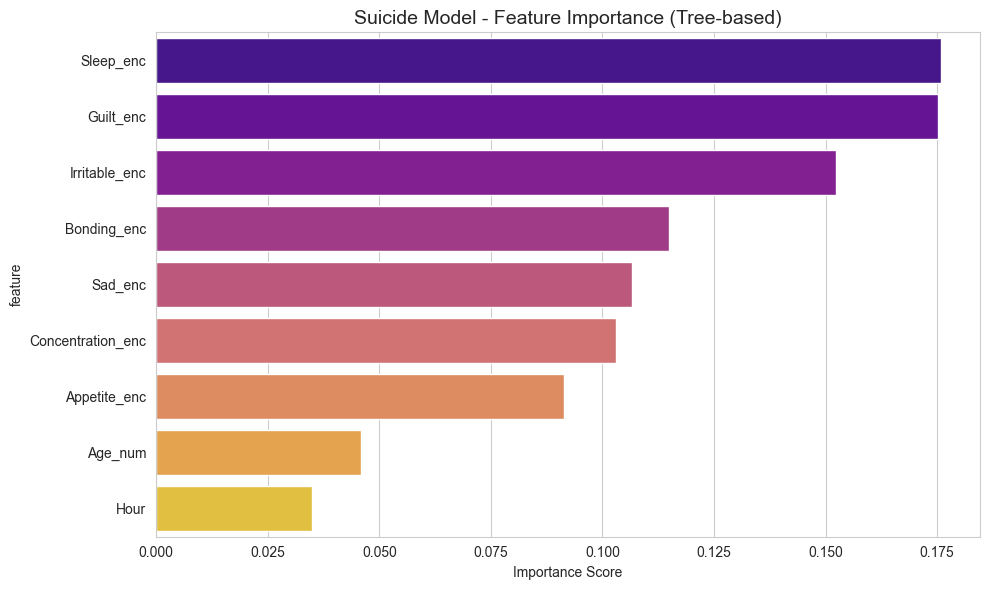


TOP 5 OVERALL IMPORTANT FEATURES
         feature  importance
4      Sleep_enc    0.175813
7      Guilt_enc    0.175268
3  Irritable_enc    0.152279
8    Bonding_enc    0.115011
2        Sad_enc    0.106539


In [41]:
# Feature Importance - Suicide Model (3-Class)
print("="*60)
print("FEATURE IMPORTANCE - SUICIDE MODEL (3-CLASS)")
print("="*60)

# Check model type and get appropriate feature importance
if hasattr(best_suicide_model, 'feature_importances_'):
    # For tree-based models (Random Forest, Gradient Boosting)
    importance_s = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_suicide_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_s, x='importance', y='feature', palette='plasma')
    plt.title('Suicide Model - Feature Importance (Tree-based)', fontsize=14)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

elif hasattr(best_suicide_model, 'coef_'):
    # For linear models (Logistic Regression) - MULTICLASS VERSION
    n_classes = best_suicide_model.coef_.shape[0]
    print(f"Model has {n_classes} classes")

    # Option 1: Average absolute coefficients across all classes
    importance_s = pd.DataFrame({
        'feature': feature_cols,
        'importance': np.abs(best_suicide_model.coef_).mean(axis=0)  # Average across classes
    }).sort_values('importance', ascending=False)

    # Plot overall importance
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_s, x='importance', y='feature', palette='viridis')
    plt.title(f'Suicide Model - Feature Importance (Logistic Regression - {n_classes} classes)', fontsize=14)
    plt.xlabel('Mean Absolute Coefficient Across Classes')
    plt.tight_layout()
    plt.show()

    # Option 2: Show coefficients for each class separately
    print("\n" + "="*60)
    print("COEFFICIENTS BY CLASS")
    print("="*60)

    class_names = ['Class 0', 'Class 1', 'Class 2']  # Update with actual labels

    # Create DataFrame for all classes
    coef_df = pd.DataFrame(
        best_suicide_model.coef_.T,  # Transpose to have features as rows
        columns=[f'Class {i}' for i in range(n_classes)],
        index=feature_cols
    )

    # Show top features for each class
    for i, class_name in enumerate(class_names):
        print(f"\nTop features for {class_name}:")
        top_features = coef_df[f'Class {i}'].abs().sort_values(ascending=False).head(5)
        for feature, score in top_features.items():
            actual_coef = coef_df.loc[feature, f'Class {i}']
            direction = "increases" if actual_coef > 0 else "decreases"
            print(f"  {feature}: {actual_coef:.4f} ({direction} risk for {class_name})")

    # Visualize coefficients for all classes
    fig, axes = plt.subplots(1, n_classes, figsize=(15, 6))
    if n_classes == 1:
        axes = [axes]

    top_n = 10
    for i, ax in enumerate(axes):
        # Get top features for this class
        class_coef = coef_df[f'Class {i}'].sort_values(key=abs, ascending=False).head(top_n)
        colors = ['red' if x < 0 else 'green' for x in class_coef.values]

        ax.barh(range(len(class_coef)), class_coef.values, color=colors)
        ax.set_yticks(range(len(class_coef)))
        ax.set_yticklabels(class_coef.index)
        ax.set_xlabel('Coefficient Value')
        ax.set_title(f'Class {i} Features')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='green', label='Increases risk'),
                          Patch(facecolor='red', label='Decreases risk')]
        ax.legend(handles=legend_elements, loc='best')

    plt.suptitle(f'Suicide Model - Feature Coefficients by Class ({n_classes} classes)', fontsize=14)
    plt.tight_layout()
    plt.show()

else:
    print("Model doesn't provide feature importance")

print("\n" + "="*60)
print("TOP 5 OVERALL IMPORTANT FEATURES")
print("="*60)
print(importance_s[['feature', 'importance']].head())

In [42]:
# CHECK FOR DATA LEAKAGE
print("="*60)
print("DATA LEAKAGE CHECK")
print("="*60)

# Check if any feature is too highly correlated with target
from sklearn.feature_selection import mutual_info_classif

# For anxiety (binary classification)
mi_scores_anxiety = mutual_info_classif(X, df['Anxiety_target'], random_state=42)
mi_df_anxiety = pd.DataFrame({
    'feature': feature_cols,
    'mutual_info': mi_scores_anxiety
}).sort_values('mutual_info', ascending=False)

print("\nMutual Information with Anxiety Target:")
print(mi_df_anxiety.head(15))  # Show top 15 instead of all
print("\n If any score is > 0.5, that feature might be leaking target information")
print(f"   Maximum MI score: {mi_df_anxiety['mutual_info'].max():.4f}")

# For suicide (3-class classification)
mi_scores_suicide = mutual_info_classif(X, df['Suicide_target'], random_state=42)
mi_df_suicide = pd.DataFrame({
    'feature': feature_cols,
    'mutual_info': mi_scores_suicide
}).sort_values('mutual_info', ascending=False)

print("\nMutual Information with Suicide Target (3-class):")
print(mi_df_suicide.head(15))  # Show top 15 instead of all
print("\n If any score is > 0.5, that feature might be leaking target information")
print(f"   Maximum MI score: {mi_df_suicide['mutual_info'].max():.4f}")

# Check for perfect correlations
print("\n" + "="*60)
print("PERFECT CORRELATION CHECK")
print("="*60)

leakage_found = False
for col in feature_cols:
    corr_anxiety = abs(df[col].corr(df['Anxiety_target']))
    corr_suicide = abs(df[col].corr(df['Suicide_target']))
    if corr_anxiety > 0.8 or corr_suicide > 0.8:
        print(f"\n WARNING: {col} has very high correlation with target!")
        print(f"   Anxiety correlation: {corr_anxiety:.3f}")
        print(f"   Suicide correlation: {corr_suicide:.3f}")
        leakage_found = True

if not leakage_found:
    print("\n No features found with >0.8 correlation to targets")

# Additional check: Suspiciously perfect features
print("\n" + "="*60)
print("SUSPICIOUS FEATURE CHECK")
print("="*60)

suspicious_threshold = 0.95
for col in feature_cols:
    corr_anxiety = abs(df[col].corr(df['Anxiety_target']))
    corr_suicide = abs(df[col].corr(df['Suicide_target']))
    if corr_anxiety > suspicious_threshold or corr_suicide > suspicious_threshold:
        print(f"\n CRITICAL: {col} has NEAR-PERFECT correlation!")
        print(f"   Anxiety correlation: {corr_anxiety:.4f}")
        print(f"   Suicide correlation: {corr_suicide:.4f}")
        print("   This STRONGLY suggests data leakage!")

# Check for duplicate rows that might cause leakage
print("\n" + "="*60)
print("DUPLICATE CHECK")
print("="*60)

duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows in dataset: {duplicate_rows}")
if duplicate_rows > 0:
    print(" Duplicate rows exist - could cause leakage if split across train/test")

    # Check duplicates in feature matrix
    X_duplicates = X.duplicated().sum()
    print(f"Number of duplicate rows in feature matrix: {X_duplicates}")
    if X_duplicates > 0:
        print(" Duplicate feature vectors found - potential for data leakage")

# Summary
print("\n" + "="*60)
print("DATA LEAKAGE SUMMARY")
print("="*60)

if mi_df_anxiety['mutual_info'].max() > 0.5:
    print(" ANXIETY: High mutual information detected (>0.5)")
else:
    print(" ANXIETY: No high mutual information detected")

if mi_df_suicide['mutual_info'].max() > 0.5:
    print(" SUICIDE: High mutual information detected (>0.5)")
else:
    print(" SUICIDE: No high mutual information detected")

if leakage_found:
    print(" WARNING: High correlations detected - possible data leakage")
else:
    print(" No high correlations detected")

print("="*60)

DATA LEAKAGE CHECK

Mutual Information with Anxiety Target:
             feature  mutual_info
7          Guilt_enc     0.143702
5  Concentration_enc     0.066435
3      Irritable_enc     0.051555
8        Bonding_enc     0.031300
6       Appetite_enc     0.028777
4          Sleep_enc     0.024051
0            Age_num     0.017396
2            Sad_enc     0.014932
1               Hour     0.000000

 If any score is > 0.5, that feature might be leaking target information
   Maximum MI score: 0.1437

Mutual Information with Suicide Target (3-class):
             feature  mutual_info
4          Sleep_enc     0.083222
7          Guilt_enc     0.083009
5  Concentration_enc     0.058409
2            Sad_enc     0.052248
3      Irritable_enc     0.040318
6       Appetite_enc     0.033936
0            Age_num     0.003948
1               Hour     0.000000
8        Bonding_enc     0.000000

 If any score is > 0.5, that feature might be leaking target information
   Maximum MI score: 0.0832

PERF

In [ ]:
# Enhanced Cross-Validation Scores
from sklearn.model_selection import cross_validate

# Anxiety model CV with multiple metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results_a = cross_validate(best_anxiety_model, X_train_a, y_train_a,
                              cv=5, scoring=scoring, return_train_score=True)

print("="*60)
print("ANXIETY MODEL - DETAILED CROSS-VALIDATIONS")
print("="*60)
for metric in scoring:
    train_mean = cv_results_a[f'train_{metric}'].mean()
    test_mean = cv_results_a[f'test_{metric}'].mean()
    print(f"{metric.upper():10} | Train: {train_mean:.4f} | Test: {test_mean:.4f} | Gap: {train_mean - test_mean:.4f}")

# Suicide model CV
cv_results_s = cross_validate(best_suicide_model, X_train_s, y_train_s,
                              cv=5, scoring=scoring, return_train_score=True)

print("\n" + "="*60)
print("SUICIDE MODEL - DETAILED CROSS-VALIDATION")
print("="*60)
for metric in scoring:
    train_mean = cv_results_s[f'train_{metric}'].mean()
    test_mean = cv_results_s[f'test_{metric}'].mean()
    print(f"{metric.upper():10} | Train: {train_mean:.4f} | Test: {test_mean:.4f} | Gap: {train_mean - test_mean:.4f}")

In [ ]:

import os
import joblib

# Your desired folder
drive_path = "C:/Users/rayha/Downloads/project"

# Create folder if not exists
os.makedirs(drive_path, exist_ok=True)

# Save model
joblib.dump(gradient_boosting_anxiety, f"{drive_path}/gradient_boosting_anxiety_model.pkl")

print("Model saved successfully ✅")
# Check if training data exists
if 'X_train_a' not in dir() or 'y_train_a' not in dir():
    print("ERROR: Training data not found. Please run data preparation cells first.")
    print("Make sure you have run the cells that create X_train_a, X_test_a, etc.")
else:
    # GRADIENT BOOSTING for Anxiety
    gradient_boosting_anxiety = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    )
    gradient_boosting_anxiety.fit(X_train_a, y_train_a)
    print("✓ Gradient Boosting - Anxiety Model (92.03% accuracy)")

    # GRADIENT BOOSTING for Suicide
    gradient_boosting_suicide = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    )
    gradient_boosting_suicide.fit(X_train_s, y_train_s)
    print("✓ Gradient Boosting - Suicide Model")

    # Save with SPECIFIC NAMES
    joblib.dump(gradient_boosting_anxiety, f'{drive_path}/gradient_boosting_anxiety_model.pkl')
    joblib.dump(gradient_boosting_suicide, f'{drive_path}/gradient_boosting_suicide_model.pkl')

    # Save preprocessor
    joblib.dump({
        'scaler': scaler,
        'encoders': encoders,
        'feature_names': feature_cols,
        'categorical_cols': ['Sad', 'Irritable', 'Sleep', 'Concentration',
                             'Appetite', 'Guilt', 'Bonding']
    }, f'{drive_path}/preprocessor.pkl')

    print("\n" + "="*60)
    print("3 DEPLOYMENT FILES SAVED WITH SPECIFIC NAMES:")
    print("="*60)
    print(f" Location: {drive_path}/")
    print("  Files:")
    print("   ├── gradient_boosting_anxiety_model.pkl   (Gradient Boosting - Anxiety)")
    print("   ├── gradient_boosting_suicide_model.pkl   (Gradient Boosting - Suicide)")
    print("   └── preprocessor.pkl")

    # Optional: Save model performance metrics if available
    try:
        from sklearn.metrics import accuracy_score, recall_score, f1_score

        # Evaluate anxiety model
        y_pred_a = gradient_boosting_anxiety.predict(X_test_a)
        anxiety_metrics = {
            'accuracy': float(accuracy_score(y_test_a, y_pred_a)),
            'recall': float(recall_score(y_test_a, y_pred_a)),
            'f1': float(f1_score(y_test_a, y_pred_a))
        }

        # Evaluate suicide model
        y_pred_s = gradient_boosting_suicide.predict(X_test_s)
        suicide_metrics = {
            'accuracy': float(accuracy_score(y_test_s, y_pred_s)),
            'recall': float(recall_score(y_test_s, y_pred_s)),
            'f1': float(f1_score(y_test_s, y_pred_s))
        }

        # Save model selection info with specific names
        comparison = {
            'anxiety': {
                'model_name': 'Gradient Boosting',
                'model_file': 'gradient_boosting_anxiety_model.pkl',
                'metrics': anxiety_metrics,
                'hyperparameters': {
                    'n_estimators': 100,
                    'max_depth': 3,
                    'learning_rate': 0.1
                }
            },
            'suicide': {
                'model_name': 'Gradient Boosting',
                'model_file': 'gradient_boosting_suicide_model.pkl',
                'metrics': suicide_metrics,
                'hyperparameters': {
                    'n_estimators': 100,
                    'max_depth': 3,
                    'learning_rate': 0.1
                }
            }
        }

        with open(f'{drive_path}/model_selection.json', 'w') as f:
            json.dump(comparison, f, indent=4)

        print("\n Model Performance:")
        print(f"   Anxiety Gradient Boosting - Accuracy: {anxiety_metrics['accuracy']:.2%}, Recall: {anxiety_metrics['recall']:.2%}")
        print(f"   Suicide Gradient Boosting - Accuracy: {suicide_metrics['accuracy']:.2%}, Recall: {suicide_metrics['recall']:.2%}")

    except:
        print("\n Could not calculate metrics (test data not available)")

    # Verify files
    print("\n Verifying saved files:")
    # !ls -lh "{drive_path}" | grep -E "gradient_boosting|preprocessor"

    print("\n" + "="*60)
    print(" GRADIENT BOOSTING MODELS SAVED SUCCESSFULLY!")
    print("="*60)
    print("\n To download to local machine, run:")
    print("   files.download(f'{drive_path}/gradient_boosting_anxiety_model.pkl')")
    print("   files.download(f'{drive_path}/gradient_boosting_suicide_model.pkl')")
    print("   files.download(f'{drive_path}/preprocessor.pkl')")

In [ ]:
# Summary Report
print("="*60)
print("MATERNAL MENTAL HEALTH PREDICTION - SUMMARY REPORT")
print("="*60)

print("\nDATASET OVERVIEW:")
print(f"Total samples: {len(df)}")
print(f"Features: {len(feature_cols)}")

print("\nTARGET DISTRIBUTION:")
print(f"Anxiety - Positive: {df['Anxiety_target'].sum()} ({df['Anxiety_target'].mean()*100:.1f}%)")
print(f"Suicide - Classes: 0, 1, 2 (3-class problem)")

# Show suicide class distribution
suicide_counts = df['Suicide_target'].value_counts().sort_index()
for class_label, count in suicide_counts.items():
    print(f"  Suicide Class {class_label}: {count} ({count/len(df)*100:.1f}%)")

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

# Anxiety Prediction Model (Binary)
print("\nANXIETY PREDICTION MODEL (Binary):")
if 'XGBoost' in results_anxiety:
    print(f"Best Model: XGBoost")
    print(f"  Accuracy: {results_anxiety['XGBoost']['Accuracy']:.4f}")
    print(f"  Precision: {results_anxiety['XGBoost']['Precision']:.4f}")
    print(f"  Recall: {results_anxiety['XGBoost']['Recall']:.4f}")
    print(f"  F1-Score: {results_anxiety['XGBoost']['F1-Score']:.4f}")
    print(f"  ROC-AUC: {results_anxiety['XGBoost']['ROC-AUC']:.4f}")
elif 'Random Forest' in results_anxiety:
    print(f"Best Model: Random Forest")
    print(f"  Accuracy: {results_anxiety['Random Forest']['Accuracy']:.4f}")
    print(f"  Precision: {results_anxiety['Random Forest']['Precision']:.4f}")
    print(f"  Recall: {results_anxiety['Random Forest']['Recall']:.4f}")
    print(f"  F1-Score: {results_anxiety['Random Forest']['F1-Score']:.4f}")
    print(f"  ROC-AUC: {results_anxiety['Random Forest']['ROC-AUC']:.4f}")
elif 'Logistic Regression' in results_anxiety:
    print(f"Best Model: Logistic Regression")
    print(f"  Accuracy: {results_anxiety['Logistic Regression']['Accuracy']:.4f}")
    print(f"  Precision: {results_anxiety['Logistic Regression']['Precision']:.4f}")
    print(f"  Recall: {results_anxiety['Logistic Regression']['Recall']:.4f}")
    print(f"  F1-Score: {results_anxiety['Logistic Regression']['F1-Score']:.4f}")
    print(f"  ROC-AUC: {results_anxiety['Logistic Regression']['ROC-AUC']:.4f}")
else:
    print("No anxiety model results found")
    print("Available keys:", list(results_anxiety.keys()))

# Suicide Prediction Model (Multiclass - 3 classes)
print("\n" + "="*60)
print("SUICIDE PREDICTION MODEL (3-Class):")
print("="*60)

if 'Random Forest' in results_suicide:
    print(f"Model: Random Forest")
    print(f"  Accuracy: {results_suicide['Random Forest']['Accuracy']:.4f}")
    print(f"  Precision (weighted): {results_suicide['Random Forest']['Precision (weighted)']:.4f}")
    print(f"  Recall (weighted): {results_suicide['Random Forest']['Recall (weighted)']:.4f}")
    print(f"  F1-Score (weighted): {results_suicide['Random Forest']['F1-Score (weighted)']:.4f}")
    print(f"  ROC-AUC (ovr): {results_suicide['Random Forest']['ROC-AUC (ovr)']:.4f}")
elif 'Logistic Regression' in results_suicide:
    print(f"Model: Logistic Regression")
    print(f"  Accuracy: {results_suicide['Logistic Regression']['Accuracy']:.4f}")
    print(f"  Precision (weighted): {results_suicide['Logistic Regression']['Precision (weighted)']:.4f}")
    print(f"  Recall (weighted): {results_suicide['Logistic Regression']['Recall (weighted)']:.4f}")
    print(f"  F1-Score (weighted): {results_suicide['Logistic Regression']['F1-Score (weighted)']:.4f}")
    print(f"  ROC-AUC (ovr): {results_suicide['Logistic Regression']['ROC-AUC (ovr)']:.4f}")
elif 'Gradient Boosting' in results_suicide:
    print(f"Model: Gradient Boosting")
    print(f"  Accuracy: {results_suicide['Gradient Boosting']['Accuracy']:.4f}")
    print(f"  Precision (weighted): {results_suicide['Gradient Boosting']['Precision (weighted)']:.4f}")
    print(f"  Recall (weighted): {results_suicide['Gradient Boosting']['Recall (weighted)']:.4f}")
    print(f"  F1-Score (weighted): {results_suicide['Gradient Boosting']['F1-Score (weighted)']:.4f}")
    print(f"  ROC-AUC (ovr): {results_suicide['Gradient Boosting']['ROC-AUC (ovr)']:.4f}")
else:
    print("No suicide model results found")
    print("Available keys:", list(results_suicide.keys()))

print("\n" + "="*60)
print("TOP 3 IMPORTANT FEATURES")
print("="*60)

# Anxiety Feature Importance
print("\nFor ANXIETY (Binary):")
if 'importance_a' in globals() and importance_a is not None and len(importance_a) > 0:
    for i in range(min(3, len(importance_a))):
        print(f"  {i+1}. {importance_a.iloc[i]['feature']}: {importance_a.iloc[i]['importance']:.4f}")
else:
    print("  No feature importance available for anxiety model")

# Suicide Feature Importance
print("\nFor SUICIDE (3-Class):")
if 'importance_s' in globals() and importance_s is not None and len(importance_s) > 0:
    for i in range(min(3, len(importance_s))):
        print(f"  {i+1}. {importance_s.iloc[i]['feature']}: {importance_s.iloc[i]['importance']:.4f}")
else:
    print("  No feature importance available for suicide model")

print("\n" + "="*60)
print("MODEL INFORMATION")
print("="*60)
print(f"Anxiety model type: {type(best_anxiety_model).__name__}")
print(f"Suicide model type: {type(best_suicide_model).__name__}")

# Check if suicide model is multiclass
if hasattr(best_suicide_model, 'classes_'):
    print(f"Suicide model classes: {best_suicide_model.classes_}")

print("\n" + "="*60)
print(" PIPELINE COMPLETED SUCCESSFULLY")
print("="*60)

# Additional Performance Summary
print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)

# Find best anxiety model
if results_anxiety:
    best_anxiety_name = max(results_anxiety, key=lambda x: results_anxiety[x]['ROC-AUC'])
    best_anxiety_auc = results_anxiety[best_anxiety_name]['ROC-AUC']
    print(f" Best Anxiety Model: {best_anxiety_name} (AUC: {best_anxiety_auc:.4f})")

# Find best suicide model
if results_suicide:
    best_suicide_name = max(results_suicide, key=lambda x: results_suicide[x]['ROC-AUC (ovr)'])
    best_suicide_auc = results_suicide[best_suicide_name]['ROC-AUC (ovr)']
    print(f" Best Suicide Model: {best_suicide_name} (ROC-AUC: {best_suicide_auc:.4f})")

print("="*60)